## FBI Crime Visualization

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('fbi_crime_us.csv')
df.head()


,State,Population,Violent Crime,Robbery,Property Crime,Motor Vehicle Theft
0,ALABAMA,4903185,25046,3941,131133,12577
1,ALASKA,731545,6343,826,21294,2617
2,ARIZONA,7278717,33141,6410,177638,18151
3,ARKANSAS,3017804,17643,1557,86250,7420
4,CALIFORNIA,39512223,174331,52301,921114,141757


### Population vs. Violent Crime Relationship

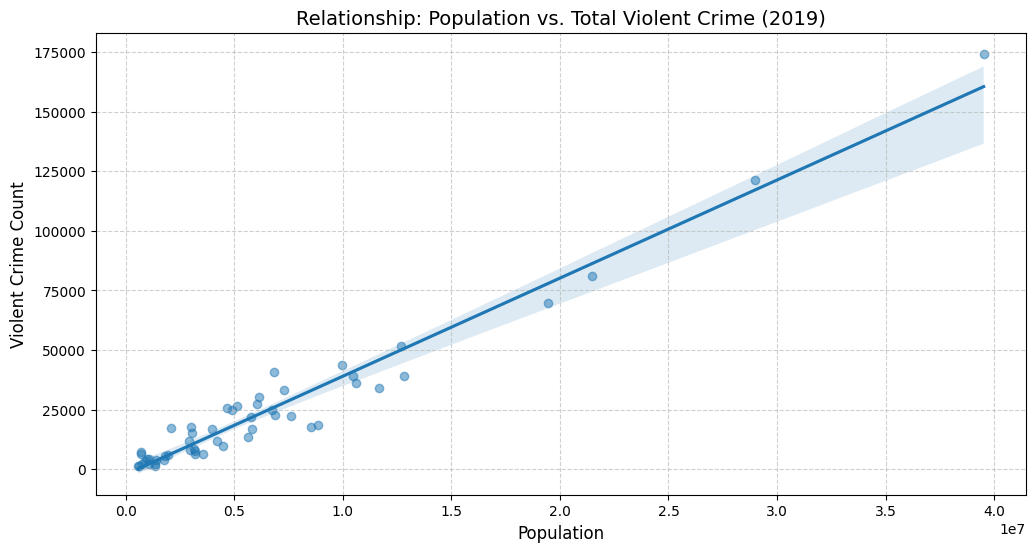

In [3]:
plt.figure(figsize=(12, 6))
sns.regplot(data=df, x='Population', y='Violent Crime', scatter_kws={'alpha':0.5})
plt.title('Relationship: Population vs. Total Violent Crime (2019)', fontsize=14)
plt.xlabel('Population', fontsize=12)
plt.ylabel('Violent Crime Count', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


### Top 10 States by Violent Crime Rate (per 100k)

C:\Users\DELL\AppData\Local\Temp\ipykernel_32012\838863835.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_10_rates, x='Violent Crime Rate', y='State', palette='viridis')


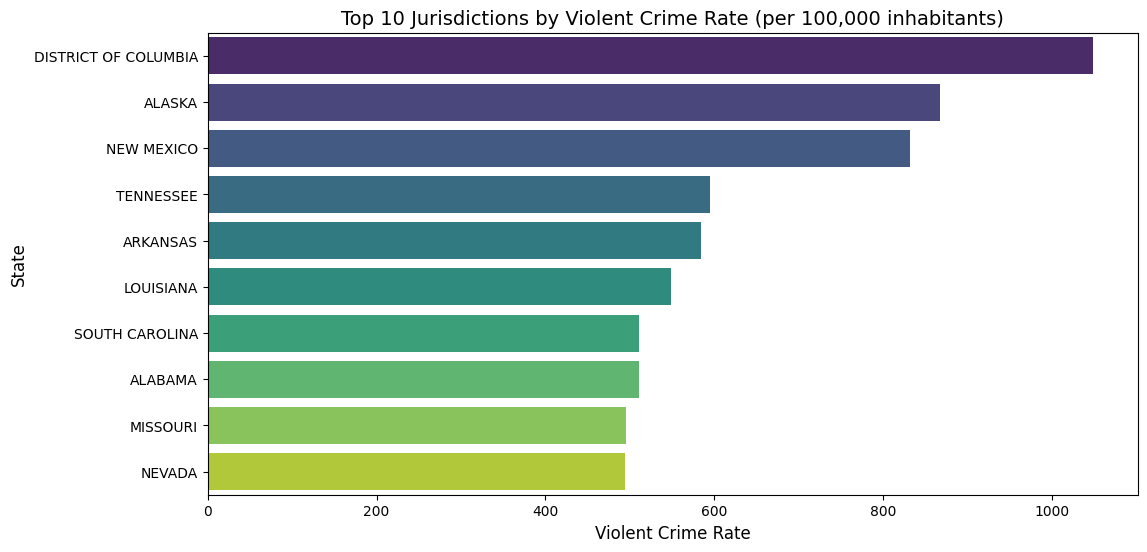

In [4]:

df['Violent Crime Rate'] = (df['Violent Crime'] / df['Population']) * 100000

top_10_rates = df.sort_values('Violent Crime Rate', ascending=False).head(10)

plt.figure(figsize=(12, 6))
sns.barplot(data=top_10_rates, x='Violent Crime Rate', y='State', palette='viridis')
plt.title('Top 10 Jurisdictions by Violent Crime Rate (per 100,000 inhabitants)', fontsize=14)
plt.xlabel('Violent Crime Rate', fontsize=12)
plt.ylabel('State', fontsize=12)
plt.show()


### Property vs. Violent Crime Composition (Top 10 Most Populous States)

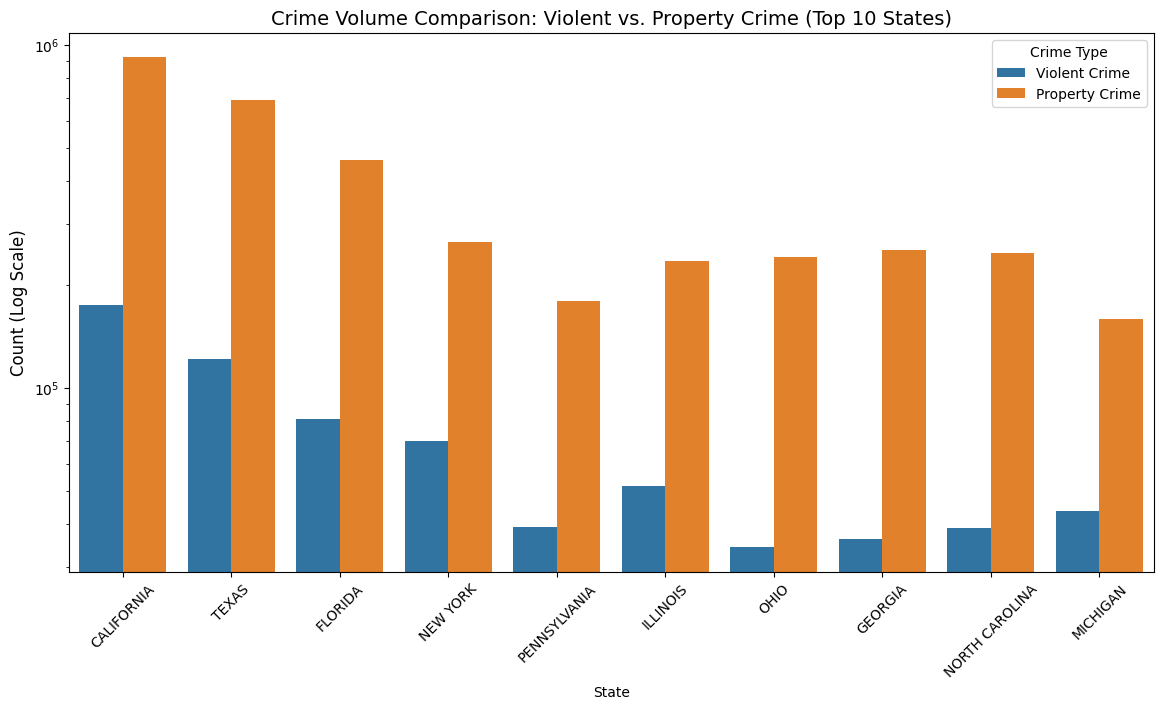

In [5]:

top_pop = df.sort_values('Population', ascending=False).head(10)

plot_data = top_pop.melt(id_vars='State', value_vars=['Violent Crime', 'Property Crime'], var_name='Crime Type', value_name='Count')

plt.figure(figsize=(14, 7))
sns.barplot(data=plot_data, x='State', y='Count', hue='Crime Type')
plt.yscale('log') 
plt.title('Crime Volume Comparison: Violent vs. Property Crime (Top 10 States)', fontsize=14)
plt.ylabel('Count (Log Scale)', fontsize=12)
plt.xticks(rotation=45)
plt.legend(title='Crime Type')
plt.show()
